# Exercises week 35

**FYS-STK3155/4155 — Applied Data Analysis and Machine Learning**

**August 24–30, 2026. Deadline: Friday August 28 at midnight.**

Reading for this set: the book, Chapter 3 (in particular Sections 3.1–3.7 from
week 34 and Sections 3.7–3.10 and 3.13 from this week), and the week 35 slides
(`week35slides.pdf`, `week35tuesday.pdf`). The Tuesday session and its notebook
(`week35tuesday.ipynb`) walk through most of the code you need here. For
exercise 1 the book by Faisal, Ong and Deisenroth, *Mathematics for Machine
Learning*, chapter 5 (sections 5.3–5.5) at https://mml-book.github.io/ is very
useful.

## Exercise 1: Analytical exercises

In this exercise we derive the expressions for various derivatives of products of
vectors and matrices. Such derivatives are central to the optimization of various
cost functions. Although we will often use automatic differentiation in actual
calculations, having the analytical expressions is extremely helpful in case we
have simpler derivatives, as well as when we analyze various properties (like
second derivatives) of the chosen cost functions. Vectors are always written as
boldfaced lower-case letters and matrices as upper-case boldfaced letters.

Show that

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{a}^T,
$$

and

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = \boldsymbol{a}^T\left(\boldsymbol{A}+\boldsymbol{A}^T\right),
$$

and

$$
\frac{\partial \left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)}{\partial \boldsymbol{s}} = -2\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\boldsymbol{A},
$$

and finally find the second derivative of this function with respect to the vector
$\boldsymbol{s}$.

If we replace the vector $\boldsymbol{s}$ with the unknown parameters
$\boldsymbol{\theta}$ used to define the ordinary least squares method, we end up
with the equations that determine these parameters. The matrix $\boldsymbol{A}$ is
then the design matrix $\boldsymbol{X}$, and $\boldsymbol{x}$ has to be replaced
with the outputs $\boldsymbol{y}$. The second derivative of the mean squared error
is then proportional to the Hessian matrix
$\boldsymbol{H}=\boldsymbol{X}^T\boldsymbol{X}$.

**Hint:** it is always useful to write out with summation indices the various
quantities; take a look at the examples in the week 35 slides. As an example,
consider the function

$$
f(\boldsymbol{x}) = \boldsymbol{A}\boldsymbol{x},
$$

which reads for a specific component $f_i$ (defining $\boldsymbol{A}$ to be an
$n\times n$ matrix and $\boldsymbol{x}$ a vector of length $n$)

$$
f_i = \sum_{j=0}^{n-1} a_{ij} x_j,
$$

which leads to

$$
\frac{\partial f_i}{\partial x_j} = a_{ij},
$$

and written out in terms of the vector $\boldsymbol{x}$ we have

$$
\frac{\partial f(\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{A}.
$$

### Solution:

#### Show that $\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{a}^T$:

Writing out the inner product with summation indices,
$$
\boldsymbol{a}^\top\boldsymbol{x} = \sum_{j=0}^{n-1} a_j x_j.
$$

Differentiating with respect to a single component $x_i$, every term with $j \neq i$ vanishes, leaving
$$
\frac{\partial (\boldsymbol{a}^\top\boldsymbol{x})}{\partial x_i} = \sum_{j=0}^{n-1} a_j \frac{\partial x_j}{\partial x_i} = a_i,
$$
since $\partial x_j/\partial x_i = \delta_{ij}$.

Collecting the components into a row vector gives
$$
\frac{\partial (\boldsymbol{a}^\top\boldsymbol{x})}{\partial \boldsymbol{x}} = [a_0, a_1, \dots, a_{n-1}] = \boldsymbol{a}^\top.
$$

#### Show that $\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = \boldsymbol{a}^T\left(\boldsymbol{A}+\boldsymbol{A}^T\right)$:

Write the scalar $f(\boldsymbol{a}) = \boldsymbol{a}^\top\boldsymbol{A}\boldsymbol{a}$ with summation indices,
$$
f = \sum_{i=0}^{n-1}\sum_{j=0}^{n-1} a_i A_{ij} a_j.
$$

Differentiating with respect to a single component $a_k$, the variable $a_k$ appears both as $a_i$ (when $i=k$) and as $a_j$ (when $j=k$), so the product rule gives two contributions,
$$
\frac{\partial f}{\partial a_k} = \sum_{j=0}^{n-1} A_{kj} a_j + \sum_{i=0}^{n-1} a_i A_{ik}.
$$

The first sum is the $k$-th component of $\boldsymbol{A}\boldsymbol{a}$, and the second is the $k$-th component of $\boldsymbol{A}^\top\boldsymbol{a}$. Collecting the components into a row vector,
$$
\frac{\partial (\boldsymbol{a}^\top\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = (\boldsymbol{A}\boldsymbol{a})^\top + (\boldsymbol{A}^\top\boldsymbol{a})^\top = \boldsymbol{a}^\top\boldsymbol{A}^\top + \boldsymbol{a}^\top\boldsymbol{A} = \boldsymbol{a}^\top\left(\boldsymbol{A}+\boldsymbol{A}^\top\right).
$$



## Exercise 2: Making your own data and exploring scikit-learn

We will generate our own dataset for a function $y(x)$ where $x\in[0,1]$ and
defined by random numbers computed with the uniform distribution. The function $y$
is a quadratic polynomial in $x$ with added stochastic noise according to the
normal distribution $\mathcal{N}(0,1)$. The following simple Python instructions
define our $x$ and $y$ values (with 100 data points).

In [35]:
import numpy as np

rng = np.random.default_rng(2026)
x = rng.random((100, 1))
y = 2.0 + 5.0 * x * x + 0.1 * rng.standard_normal((100, 1))

1. Write your own code (following the examples in the book, Chapter 3, and the
   week 34–35 slides) for computing the parametrization of the data set, fitting a
   second-order polynomial. That is, set up the design matrix
   $\boldsymbol{X}$ with columns $1, x, x^2$ and find the optimal parameters
   $\boldsymbol{\theta}$ from the normal equations (or, better, through the SVD —
   see the week 34 discussion of why we never invert
   $\boldsymbol{X}^T\boldsymbol{X}$).

2. Use thereafter **scikit-learn** (see the examples in the week 35 slides and the
   Tuesday notebook) and compare with your own code. Note that scikit-learn does
   not, by default, include the intercept in the design matrix. See the
   discussions on scaling your data in the week 35 slides (and Section 3.13 of the
   book). This type of problem appears in particular if we fit a polynomial with
   an intercept.

3. Using scikit-learn, compute also the mean squared error, a risk metric
   corresponding to the expected value of the squared (quadratic) error

$$
MSE(\boldsymbol{y},\tilde{\boldsymbol{y}}) = \frac{1}{n}\sum_{i=0}^{n-1}\left(y_i-\tilde{y}_i\right)^2,
$$

   and the $R^2$ score function. If $\tilde{y}_i$ is the predicted value of the
   $i$-th sample and $y_i$ is the corresponding true value, then the $R^2$ score is

$$
R^2(\boldsymbol{y},\tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y})^2},
$$

   where the mean value of $\boldsymbol{y}$ is

$$
\bar{y} = \frac{1}{n}\sum_{i=0}^{n-1} y_i.
$$

   You can use the functionality included in scikit-learn, or your own functions
   from the Tuesday notebook. Discuss the meaning of these results. Try also to
   vary the coefficient in front of the added stochastic noise term and discuss
   the quality of the fits.

In [36]:
# Your code for exercise 2 here

degree = 2

X = np.column_stack([x**i for i in range(degree + 1)])

def ols(X, y):
    """Ordinary least squares through singular value decomposition.""" 
    U, s, Vt = np.linalg.svd(X, full_matrices=False) 
    return Vt.T @ (U.T @ y / s)

y = y.ravel()

reg = ols(X, y)
reg

array([ 2.02956252, -0.04832909,  5.01856665])

Our OLS regression through SVD gave us the model 
$$
\tilde{y} \approx 2.03 - 0.05x + 5.02x^2.
$$
As we know the true function $y$ which created the data, we know that this is a farily good estimation of $y=2+5x^2$.

Next, we can double check the results of our OLS function my cross referencing it against scikit-learn's `LinearRegression` model which also uses OLS.

In [37]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression(fit_intercept=False).fit(X, y)
print(reg.coef_)

[ 2.02956252 -0.04832909  5.01856665]


Here we see that the coeffisients of the model made from the scikit-learn library are the same as from our OLS implementation.

Next, we can compute the MSE and R2 values of the model we have created.

In [38]:
from sklearn.metrics import mean_squared_error, r2_score

y_tilde = reg.predict(X)

mse = mean_squared_error(y, y_tilde)
r2  = r2_score(y, y_tilde)

print(f"{mse = }, {r2 = }")

mse = 0.01372815674626301, r2 = 0.9928732429893427


We observe a low value for the MSE, indicating the true values are close to the regression line we have made. We also see an R2 score just under 1, which means that almost all the variation in the data is explained by the model, with less than a percentage being unexplainable noise (stemming from the `+ 0.1 * rng.standard_normal((100, 1))` that is within $y$).

If we were to increase the noise multiplier, we observe that the MSE score increases, as the prediction for each point is less certain, due to unleranable noise; as well as the R2 score dropping, as less of the variation in the data can be explained by the model – due to a larger part being explained by random noise.

## Exercise 3: Split data in test and training data

In this exercise we want you to compute the MSE for the training data and the test
data as a function of the complexity of a polynomial, that is the degree of a given
polynomial.

The aim is to reproduce Figure 2.11 of Hastie et al., *The Elements of Statistical
Learning*. Feel free to read the discussions leading to that figure.

Our data is defined by $x\in[-3,3]$ with a total of, for example, $n=100$ data
points. You should try to vary the number of data points $n$ in your analysis.

In [39]:
n = 100
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + rng.normal(0, 0.1, x.shape)
y = y.ravel()

where $y$ is the function we want to fit with a given polynomial.

1. Write a first code which sets up a design matrix $\boldsymbol{X}$ defined by a
   fifth-order polynomial and split your data set into training and test data
   (`sklearn.model_selection.train_test_split` is fine).

2. Write thereafter (using either scikit-learn or your matrix inversion/SVD code)
   an ordinary least squares fit and compute the mean squared error for the
   training data and the test data. These calculations should apply to a model
   given by a fifth-order polynomial. If you compare your own code with
   scikit-learn, note that the latter does not include the intercept by default —
   see the discussions on scaling in the week 35 slides.

3. Add now a model which allows you to make polynomials up to degree $15$. Perform
   a standard OLS fit of the training data and compute the MSE for the training
   and test data and plot both as functions of the polynomial degree. Compare what
   you see with Figure 2.11 of Hastie et al. Comment on your results. For which
   polynomial degree do you find the optimal (smallest) test MSE?

In [40]:
# Your code for exercise 3 here

degree = 5

X = np.column_stack([x**i for i in range(degree + 1)])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
# Fit regression model
reg = ols(X_train, y_train)

y_pred_train = X_train @ reg
y_pred_test = X_test @ reg

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"{mse_train = } and {mse_test = }")

mse_train = 0.030598754916690375 and mse_test = 0.02931342508539207


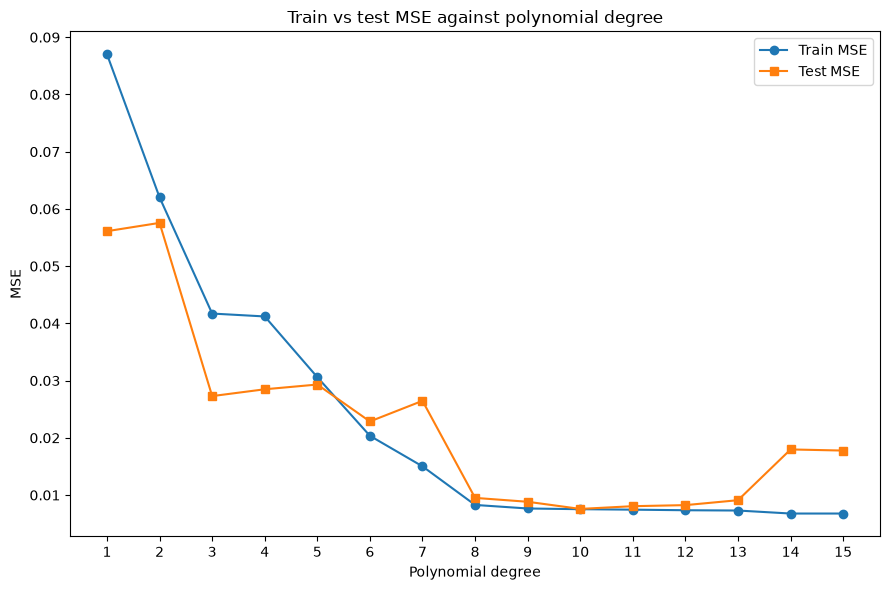

Optimal degree (min test MSE): 10, test MSE = 0.00758


In [42]:
import matplotlib.pyplot as plt

max_degree = 15
degrees = range(1, max_degree + 1)

mse_train_list = []
mse_test_list = []

for degree in degrees:
    X = np.column_stack([x**i for i in range(degree + 1)])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    reg = ols(X_train, y_train)

    mse_train_list.append(mean_squared_error(y_train, X_train @ reg))
    mse_test_list.append(mean_squared_error(y_test, X_test @ reg))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(degrees, mse_train_list, "o-", label="Train MSE")
ax.plot(degrees, mse_test_list, "s-", label="Test MSE")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.set_title("Train vs test MSE against polynomial degree")
ax.set_xticks(list(degrees))
ax.legend()
plt.tight_layout()
plt.show()

# Degree with smallest test MSE
best_degree = degrees[int(np.argmin(mse_test_list))]
print(f"Optimal degree (min test MSE): {best_degree}, "
      f"test MSE = {min(mse_test_list):.5f}")

We see the same trend as in Figure 2.11 of Hastie et al.: the training MSE decreases monotonically as the polynomial degree grows, while the test MSE follows a U-shape — it falls initially, reaches a minimum, and then rises again. The training error keeps dropping because a higher-degree polynomial has more free parameters and can always fit the training points more closely. The test error rises past the minimum because the extra flexibility starts fitting the (random) noise in the training data rather than the underlying structure, so the model generalizes worse to unseen data. This is the bias–variance trade-off: low degrees underfit (high bias), high degrees overfit (high variance), and the optimal degree sits at the bottom of the U where the test MSE is smallest. We find the smallest test MSE at degree 10, with a test MSE of 0.00758. In practice this means we should not choose a more complex model than the data and problem warrant. One caveat: with a single train/test split the exact location of the minimum is somewhat noisy and can shift with the random seed, so the optimal degree is best confirmed with resampling or cross-validation.

## Exercise 4 (optional): a first taste of Ridge

This voluntary exercise connects directly to Monday's lecture and to Case 4 of the
Tuesday notebook; it is also a useful warm-up for Project 1.

Keep the data set and the degree-15 design matrix from exercise 3, standardise the
feature columns (training statistics only!), and replace OLS by Ridge regression,

$$
\hat{\boldsymbol{\theta}}_{\mathrm{Ridge}} = \left(\boldsymbol{X}^T\boldsymbol{X}+\lambda\boldsymbol{I}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}.
$$

1. Plot the training and test MSE as functions of $\lambda$ on a logarithmic grid,
   say $\lambda\in[10^{-8},10^{4}]$. Do you find the U-shape discussed in the
   lecture?

2. Compare your best test MSE with the best value found in exercise 3 by varying
   the polynomial degree. Two dials, one phenomenon — which gives the finer
   control?

3. Check explicitly that your training MSE is monotonically increasing in
   $\lambda$, and explain in one sentence why it must be.

In [43]:
# Your code for exercise 4 here
